# Imports

In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from olive_oil.data import load_dataset, average_replicates, get_spectral_matrix
from olive_oil.visualization import plot_spectra

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [8]:
data = load_dataset("../Data/CAC2026_Data_challenge.xlsx")


In [9]:
for k in data.keys():
    print(k, data[k].shape)
    if len(data[k].columns) < 10:
        print(data[k].columns)
    else:
        print(data[k].columns[0], ", ", data[k].columns[1], "...", data[k].columns[-1])
    print('\n')

labels (220, 2)
Index(['sample_id', 'label'], dtype='str')


metadata (220, 5)
Index(['sample_id', 'Grade (Lampante, Virgin, Extra Virgin - Olive Oil)',
       'Fruity intensity', 'Bitterness', 'Pungency'],
      dtype='str')


cal_uvvis (440, 702)
sample_id ,  300.0 ... 1000.0


cal_ftir (660, 550)
sample_id ,  3230.23493314452 ... 673.046002228424


cal_hsms (440, 302)
sample_id ,  50.0 ... 350.0


test_uvvis (48, 702)
sample_id ,  300.0 ... 1000.0


test_ftir (72, 550)
sample_id ,  3230.23493314452 ... 673.046002228424


test_hsms (48, 302)
sample_id ,  50.0 ... 350.0




Metadata columns:
sample_id
Grade (Lampante, Virgin, Extra Virgin - Olive Oil)
Fruity intensity
Bitterness
Pungency
label


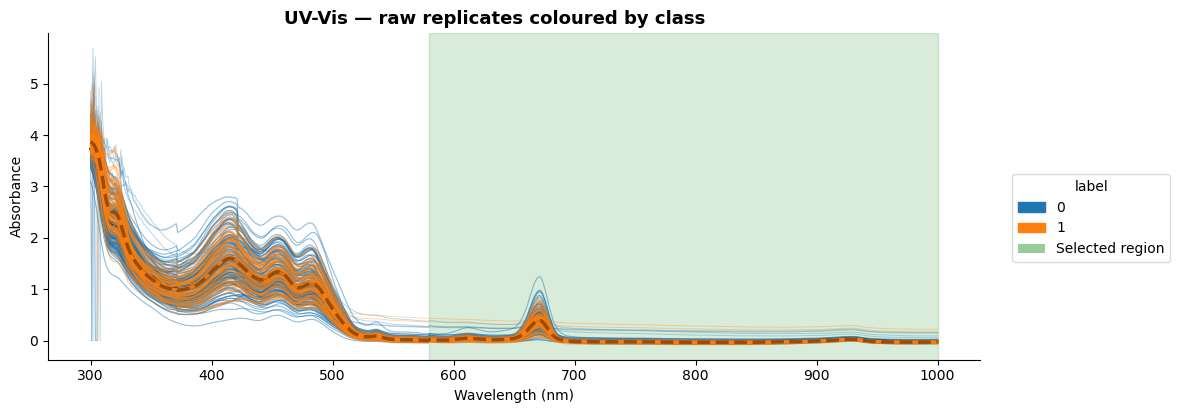

In [10]:
# Merge labels into metadata so both are available for grouping
meta = data["metadata"].merge(data["labels"], on="sample_id")

print("Metadata columns:")
for c in meta.columns:
    print(c)

# --- Example 1: raw replicates, coloured by class ---
plot_spectra(
    data["cal_uvvis"],
    metadata=meta,
    color_by="label",
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="UV-Vis — raw replicates coloured by class",
)

C:\Users\SamdGuizani\AppData\Local\Temp\ipykernel_39232\3002539008.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  average_replicates(data["cal_ftir"]).reset_index(),


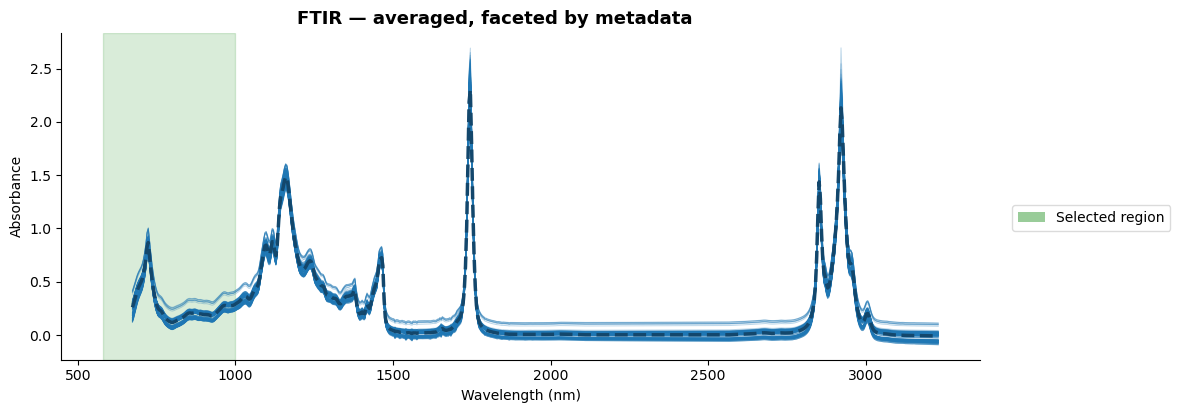

In [20]:
# --- Example 2: averaged spectra, faceted by a metadata variable ---
# Replace "your_meta_col" with an actual column from data["metadata"]
plot_spectra(
    average_replicates(data["cal_ftir"]).reset_index(),
    # metadata=meta,
    # color_by="label",
    # facet_col_by="Pungency",
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="FTIR — averaged, faceted by metadata",
)

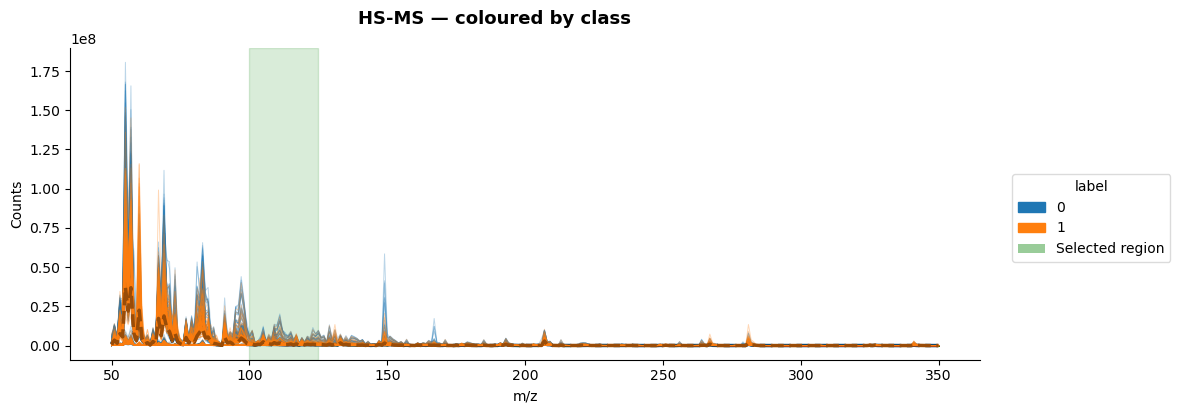

In [21]:
# --- Example 4: HS-MS with suggested region ---
plot_spectra(
    data["cal_hsms"],
    metadata=meta,
    color_by="label",
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="HS-MS — coloured by class",
)

In [12]:
meta

,sample_id,"Grade (Lampante, Virgin, Extra Virgin - Olive Oil)",Fruity intensity,Bitterness,Pungency,label
0,1,EVOO,mid,mid,mid,0
1,2,VOO,light,light,mid,1
2,3,LOO,light,light,mid,1
3,4,VOO,mid,light,mid,0
4,5,VOO,mid,mid,mid,1
...,...,...,...,...,...,...
215,216,VOO,mid,mid,mid,1
216,217,VOO,mid,mid,mid,1
217,218,LOO,mid,mid,mid,1
218,219,VOO,mid,mid,mid,0
